<a name='T'>

<p style="padding: 20px;
          background-color: black;
          font-family: computermodern;
          color: white;
          font-size: 200%;
          text-align: center;
          border-radius: 40px 20px;
          ">No-AI Coding Challenge #2 🩶 KiaKio and Squared Numbers<br>
          </p>
<p style="font-family: computermodern;
          color: #000000;
          font-size: 175%;
          text-align: center;
          ">Programming Puzzle, "Newbie" Difficulty (1000 Elo)
             </p>

Welcome to my **No-AI Coding series**! This is intended to any programmer willing to keep their brain sharp in a world where AI usually codes everything for you.

Today, I propose another easy problem, with a pinch of number theory: the [KiaKio and Squared Numbers](https://codeforces.com/problemset/problem/2269/B) puzzle from CodeForces. Let's dive into it!

<a id="TOC"></a>

<div style="background-color: #f5f5f5; border-left: 10px solid #9e9e9e; padding: 20px; margin-bottom: 20px; border-radius: 8px; box-shadow: 0 2px 5px rgba(0,0,0,0.1);">
    <h3 style="color: #616161;">Table of Contents</h3>
    <ul style="list-style-type: none;">
        <li><a href="#s1" style="color: #424242;"><strong>1. Instructions</strong></a></li>
        <li><a href="#s2" style="color: #424242;"><strong>2. Input and Output</strong></a></li>
        <li><a href="#s3" style="color: #424242;"><strong>3. Show Time!</strong></a></li>
        <li><a href="#s4" style="color: #424242;"><strong>4. Evaluation</strong></a></li>
        <li><a href="#s5" style="color: #424242;"><strong>5. Proposed Solution</strong></a></li>
    </ul>
</div>

*Notebook by Ir. Alexandre Le Mercier.*

In [1]:
import sys, os

if not os.path.exists('.git') and not os.path.exists('no-ai-coding-challenges'):
    !git clone https://github.com/TortueSagace/no-ai-coding-challenges.git -q

repo_path = 'no-ai-coding-challenges'
if os.path.exists(repo_path) and repo_path not in sys.path:
    sys.path.insert(0, repo_path)

from utils import *
from cha2_utils import *

C:\Users\Administrator\OneDrive - UGent\PhD\PhD Related Python Codes\chess-maml\chess-hispa\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<a id="s1"></a>
<div style="color: black; background-color: #E6E6FA; padding: 10px; border-left: 5px solid purple; border-radius: 5px;">  
    <h1>1. Instructions</h1>
</div>

[Back to table of contents](#TOC)

***This problem is meant to be entirely solved without AI! Time to do some brain work-out*** 💪

Kia and Kio spent the summer at the port of Mehragan, where $n$ lighthouses stand on the cliffs facing the dark sea.

The lighthouses of Mehragan do not give light. Every night a **number** is written in fire on each of them, and the sailors read their way from those numbers.

The law of the lighthouses is this: if a lighthouse shows $x$ tonight, then tomorrow night it shows the **sum of the squares of the decimal digits** of $x$.

For example, a lighthouse showing $23$ will show $2^2+3^2=13$ tomorrow, then $1^2+3^2=10$, and then $1$.

On night $0$ of the season, lighthouse $i$ shows the number $a_i$. From that night on, the law is applied once every night, forever.

Kio calls two lighthouses $i$ and $j$ **in tune** if there exists a night after which, **forever**, both of them show exactly the same number on every single night.

Kia asks: how many pairs $(i, j)$ with $i \lt j$ are in tune?

<a id="s2"></a>
<div style="color: black; background-color: #E6E6FA; padding: 10px; border-left: 5px solid purple; border-radius: 5px;">  
    <h1>2. Input and Output</h1>
</div>

[Back to table of contents](#TOC)

## Input

Your function receives:
- `n` (int): the number of lighthouses (`1 ≤ n ≤ 1000`)
- `a` (list of int): the number shown by each lighthouse on night 0 (`1 ≤ a[i] ≤ 10^9`)

**Example:**

```python
n = 5
a = [7, 4, 16, 4, 2]
```

## Output

Your function must return an int `pairs`: the number of pairs (i, j) with i < j whose lighthouses are in tune.

**Example:**

```python
pairs = 1
```

## Sample Test Cases

| n | a | Expected Output | Explanation |
|---|---|-----------------|-------------|
| 5 | `[7, 4, 16, 4, 2]` | `1` | Only the two lighthouses starting at `4` are in tune: `7` reaches `1` alone, while `16` and `2` never match anyone |
| 4 | `[1, 7, 10, 100]` | `6` | Every number reaches `1` and stays there, so all 6 pairs are in tune |
| 3 | `[4, 16, 37]` | `0` | `4 → 16 → 37 → ...`: the three lighthouses walk the same loop, always at different positions |
| 3 | `[2, 20, 4]` | `1` | `2` and `20` both show `4` on night 1 and are identical from then on; the third lighthouse is one night ahead |

<a id="s3"></a>
<div style="color: black; background-color: #E6E6FA; padding: 10px; border-left: 5px solid purple; border-radius: 5px;">  
    <h1>3. Show Time!</h1>
</div>

[Back to table of contents](#TOC)

***Time to shine! Try solving the problem by yourself. You can do it!*** 🧠

Implement your solution in the `my_solution(n, a)` function below. The function should return `pairs` as described above.

**Time limit per test**: 1 second.

**Memory limit per test**: 256 megabytes.

In [2]:
######################### SETUP ############################

samples = [
    [5, [7, 4, 16, 4, 2]],
    [4, [1, 7, 10, 100]],
    [3, [4, 16, 37]],
    [3, [2, 20, 4]]
]

TIME_LIMIT = 1
MEMORY_LIMIT = 256e6

print(f"Loaded {len(samples)} sample test cases.")

Loaded 4 sample test cases.


In [3]:
######################### RESOLUTION ###########################

def my_solution(n, a):
    """
    Count the pairs of lighthouses that end up showing the same number every night, when each
    night every number x is replaced by the sum of the squares of its decimal digits.
    
    Parameters:
    -----------
    n : int
        The number of lighthouses (1 ≤ n ≤ 1000)
    a : list of int
        The number shown by each lighthouse on night 0 (1 ≤ a[i] ≤ 10^9)
    
    Returns:
    --------
    int : the number of pairs (i, j) with i < j whose lighthouses are in tune
    """
    
    # --> Your solution here! <--
    
    pass  # Remove this and return pairs

ℹ️ **Tips**
- Run the cell below to test your solution on the sample test cases.
- Each test case has exactly one correct answer.

<div style="color: black; background-color: #ffcccc; padding: 10px; border-left: 5px solid #ff3333; border-radius: 5px;">
    <strong>Note:</strong> The evaluation compares your output with the <em>expected</em> answer.
</div>

In [4]:
##################### ACCURACY AND EFFICIENCY CHECK ########################

try:
    evaluate_on_samples(samples, my_solution, check_solution, TIME_LIMIT, MEMORY_LIMIT)
except Exception as e:
    print(e)


                       Sample Test Results                       
   # │ Input                 │ Output │         Time │ Status    
─────┼───────────────────────┼────────┼──────────────┼───────────
   1 │ [5, [7, 4, 16, 4, 2]] │ None   │      35.7 μs │ ❌ Wrong   
   2 │ [4, [1, 7, 10, 100]]  │ None   │      10.1 μs │ ❌ Wrong   
   3 │ [3, [4, 16, 37]]      │ None   │       8.2 μs │ ❌ Wrong   
   4 │ [3, [2, 20, 4]]       │ None   │       8.3 μs │ ❌ Wrong   

❌  0/4 sample tests passed
    First failure: Invalid output: function returned None. Did you run the cell containing your solution?


<a id="s4"></a>
<div style="color: black; background-color: #E6E6FA; padding: 10px; border-left: 5px solid purple; border-radius: 5px;">  
    <h1>4. Evaluation</h1>
</div>

[Back to table of contents](#TOC)

Run the cell below to evaluate your solution on 300 hidden test cases. You are supposed to be already confident about your solution before doing this. Please note that in competitive programming, submitting several wrong answers to the tester results in time penalties. However, feel free to run the cell above with `evaluate_on_samples` as many times as you like!

In [5]:
##################### INTERNAL EVALUATION ########################

test_file_path = 'no-ai-coding-challenges/cha2_tests.txt'

try:
    if internal_evaluation(test_file_path, my_solution, check_solution, parse_tests, TIME_LIMIT, MEMORY_LIMIT, get_input_size=get_input_size, plot_title='KiaKio and Squared Numbers', show_estimation=True):
        print("✅ The proposed solution meets both accuracy and efficiency requirements")
except Exception as e:
    print(e)

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]


❌  Invalid output: function returned None. Did you run the cell containing your solution?


<a id="s5"></a>
<div style="color: black; background-color: #E6E6FA; padding: 10px; border-left: 5px solid purple; border-radius: 5px;">  
    <h1>5. Proposed Solution</h1>
</div>

[Back to table of contents](#TOC)

Here is a correct solution. It doesn't necessarily mean that it is the *only* correct one.

<details>
<summary><strong>💡 Click to reveal Solution Explanation</strong></summary>

<div style="color: black; background-color: #cce5ff; padding: 10px; border-left: 5px solid #3399ff; border-radius: 5px; margin-top: 10px;">
    The key insight is that the rule is <strong>deterministic</strong>: as soon as two lighthouses show the same number on the same night, they show the same number on every following night. So two lighthouses are in tune if and only if they show the same number on <em>some</em> night, and it suffices to look at one night that is late enough.<br><br>
    <strong>How late is late enough?</strong> A number up to 10⁹ has at most 9 nonzero digits, so after one night it is at most 9 × 81 = 729. From there, a quick exhaustive check shows that every starting value reaches its final loop within 12 nights, and that there are only two final loops: the fixed point <code>1</code>, and the 8-cycle <code>4 → 16 → 37 → 58 → 89 → 145 → 42 → 20 → 4</code>. Once both lighthouses are inside their final loop, their relative position never changes: they either already match, or never will.<br><br>
    <strong>Strategy:</strong>
    <ol>
        <li>Simulate every lighthouse for a fixed number of nights (we take 20 ≥ 12).</li>
        <li>Group the lighthouses by the number they show on that night (a <code>Counter</code>).</li>
        <li>A group of size <code>c</code> contributes <code>c * (c - 1) / 2</code> pairs; sum over all groups.</li>
    </ol>
    Each lighthouse is simulated for a constant number of nights, and each night costs at most 10 digit operations, so the whole algorithm is linear in <code>n</code>.
</div>

</details><br>

The time complexity of this solution is $\mathcal O(n)$ and its space complexity is $\mathcal O(1)$.

In [6]:
######################### PROPOSED SOLUTION ###########################

from collections import Counter


def proposed_solution(n, a):
    """
    Two lighthouses are in tune iff they show the same number on a late enough night.
    Every starting value up to 10^9 reaches its final loop ({1} or the 8-cycle through 4)
    within 12 nights, so comparing the numbers shown on night 20 is enough.
    """
    NIGHTS = 20

    def next_number(x):
        # Sum of the squares of the decimal digits of x
        total = 0
        while x > 0:
            x, digit = divmod(x, 10)
            total += digit * digit
        return total

    def number_on_night(x, nights):
        for _ in range(nights):
            x = next_number(x)
        return x

    # Group the lighthouses by the number they show on night NIGHTS
    groups = Counter(number_on_night(x, NIGHTS) for x in a)

    # Inside a group of size c, all c * (c - 1) / 2 pairs are in tune
    return sum(c * (c - 1) // 2 for c in groups.values())


Testing proposed solution on hidden tests:


  0%|          | 0/300 [00:00<?, ?it/s]

 26%|██▋       | 79/300 [00:00<00:00, 784.73it/s]

 59%|█████▉    | 177/300 [00:00<00:00, 891.70it/s]

 89%|████████▉ | 267/300 [00:00<00:00, 889.61it/s]

100%|██████████| 300/300 [00:00<00:00, 862.79it/s]

✅  All 300 tests passed!


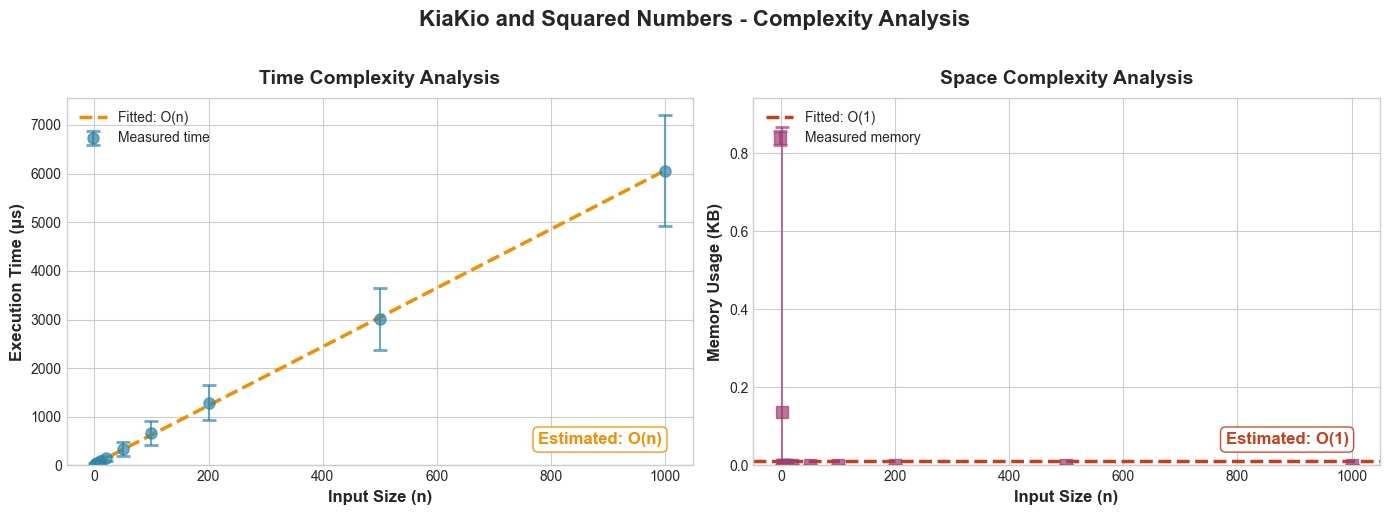


📊 Estimated Time Complexity: O(n)
📊 Estimated Space Complexity: O(1)
✅ The proposed solution meets both accuracy and efficiency requirements


In [7]:
##################### VERIFY PROPOSED SOLUTION ########################

print("\nTesting proposed solution on hidden tests:")
if internal_evaluation(test_file_path, proposed_solution, check_solution, parse_tests, TIME_LIMIT, MEMORY_LIMIT, get_input_size=get_input_size, plot_title='KiaKio and Squared Numbers', show_estimation=True):
    print("✅ The proposed solution meets both accuracy and efficiency requirements")

<p style="padding: 20px;
          background-color: green;
          font-family: computermodern;
          color: white;
          font-size: 200%;
          text-align: center;
          border-radius: 40px 20px;
          ">Thank you! If you found this useful, please upvote 👍</p>